# ArduPilot SITL Flight Data Analysis: Hold Heading Experiments

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [ ]:
# Load the data
gps_df = pd.read_csv('last_flight_gps.csv')
att_df = pd.read_csv('last_flight_att.csv')
events_df = pd.read_csv('experiment_events.csv') # timestamps of external wind
mag_df = pd.read_csv('last_flight_mag.csv')

# Clean up timestamps
for df_tmp in [gps_df, att_df, events_df, mag_df]:
    df_tmp['datetime'] = pd.to_datetime(df_tmp['timestamp'], unit='s')
    df_tmp['time_sec'] = df_tmp['timestamp'] - att_df['timestamp'].min()

# localize GPS

# Reference point 
lat0 = gps_df['Lat'].iloc[0]
lon0 = gps_df['Lng'].iloc[0]

# Earth radius in meters
R_EARTH = 6_371_000

# Convert to radians for the scale factor
lat0_rad = np.radians(lat0)

# Meters per degree at this latitude
meters_per_deg_lat = (np.pi / 180) * R_EARTH
meters_per_deg_lon = (np.pi / 180) * R_EARTH * np.cos(lat0_rad)

# Convert lat/lon to local meters (North/East)
gps_df['North_m'] = (gps_df['Lat'] - lat0) * meters_per_deg_lat
gps_df['East_m']  = (gps_df['Lng'] - lon0) * meters_per_deg_lon

In [4]:
print(f"Data Loaded: GPS ({len(gps_df)} rows), Attitude ({len(att_df)} rows)")

Data Loaded: GPS (741 rows), Attitude (3702 rows)


In [6]:
def extract_gust_periods(events):
    """Extract start/end times for each wind gust period."""
    gust_periods = []
    
    gust_on_events = events[events['event_type'] == 'GUST_ON']
    gust_off_events = events[events['event_type'] == 'GUST_OFF']
    
    for i in range(len(gust_on_events)):
        start = gust_on_events.iloc[i]['time_sec']
        if i < len(gust_off_events):
            end = gust_off_events.iloc[i]['time_sec']
            gust_periods.append((start, end))
    
    return gust_periods
gusts = extract_gust_periods(events_df)

['timestamp', 'TimeUS', 'DesRoll', 'Roll', 'DesPitch', 'Pitch', 'DesYaw', 'Yaw', 'AEKF', 'datetime', 'time_sec']


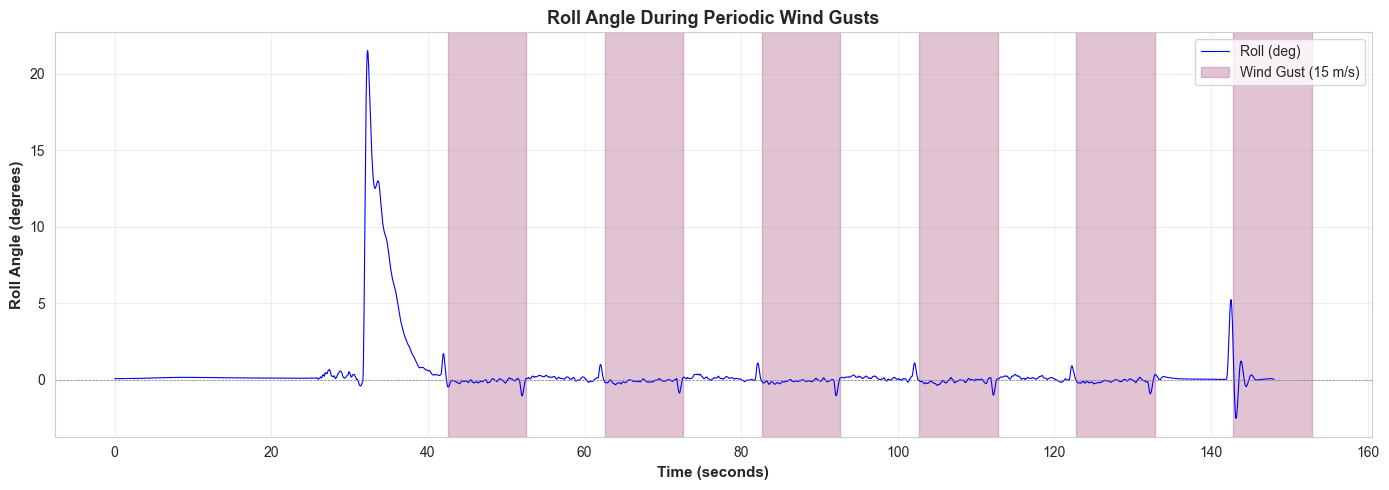

In [7]:
# roll data
print(att_df.columns.tolist())

at_df = att_df

# Gust timing parameters (must match gust_simulation.py)
GUST_DURATION = 10    # seconds
CALM_DURATION = 10   # seconds
CYCLE_PERIOD = GUST_DURATION + CALM_DURATION  # 15 seconds
# Plot
fig, ax = plt.subplots(figsize=(14, 5))
# Plot Roll angle
ax.plot(at_df['time_sec'], at_df['Roll'], 'b-', linewidth=0.8, label='Roll (deg)')
# Add shaded regions for gust periods
for i, (start, end) in enumerate(gusts):
    ax.axvspan(start, end, alpha=0.3, color='#A23B72', 
            label='Wind Gust (15 m/s)' if i == 0 else '')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_ylabel('Roll Angle (degrees)', fontsize=11, fontweight='bold')
ax.set_title('Roll Angle During Periodic Wind Gusts', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


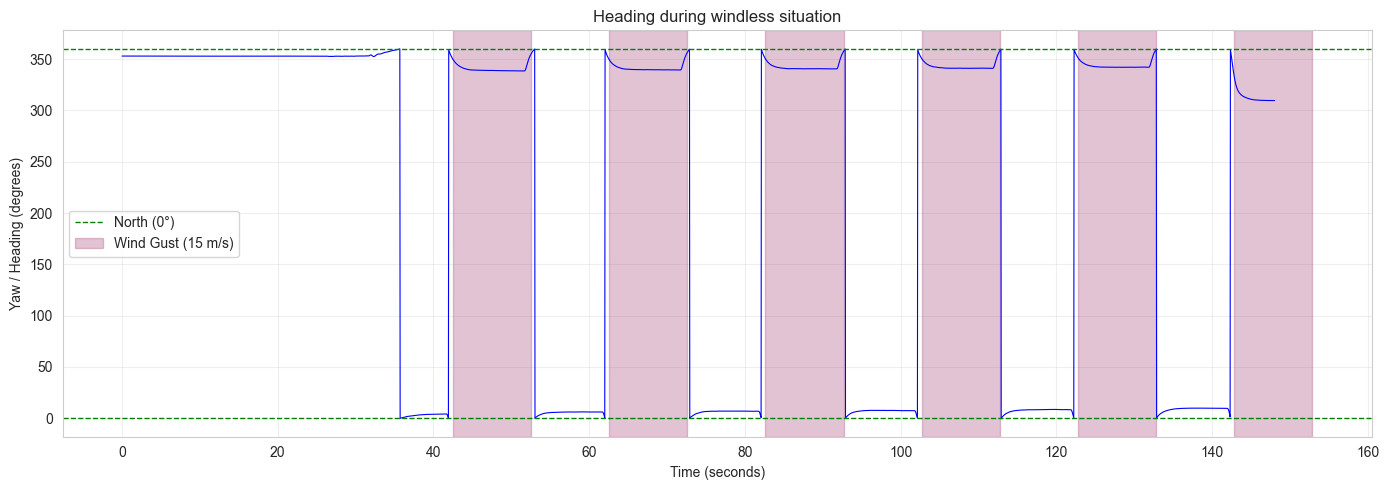

In [9]:
# yaw data

at_df = att_df
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(at_df['time_sec'], at_df['Yaw'], 'b-', linewidth=0.8)

# Add reference line for "North"
ax.axhline(0, color='green', linestyle='--', linewidth=1, label='North (0°)')
ax.axhline(360, color='green', linestyle='--', linewidth=1)

# Add gust shading (same as before)
for i, (start, end) in enumerate(gusts):
    ax.axvspan(start, end, alpha=0.3, color='#A23B72', 
            label='Wind Gust (15 m/s)' if i == 0 else '')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Yaw / Heading (degrees)')
ax.set_title('Heading during windless situation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [79]:
print(gps_df.columns.tolist())

['timestamp', 'TimeUS', 'I', 'Status', 'GMS', 'GWk', 'NSats', 'HDop', 'Lat', 'Lng', 'Alt', 'Spd', 'GCrs', 'VZ', 'Yaw', 'U', 'datetime', 'time_sec', 'North_m', 'East_m']


## 2. Data Wrangling and Cleaning

## 3. Accelerometer Data Visualization

## 4. Gyroscope Data Visualization

## 5. GPS Position Visualization

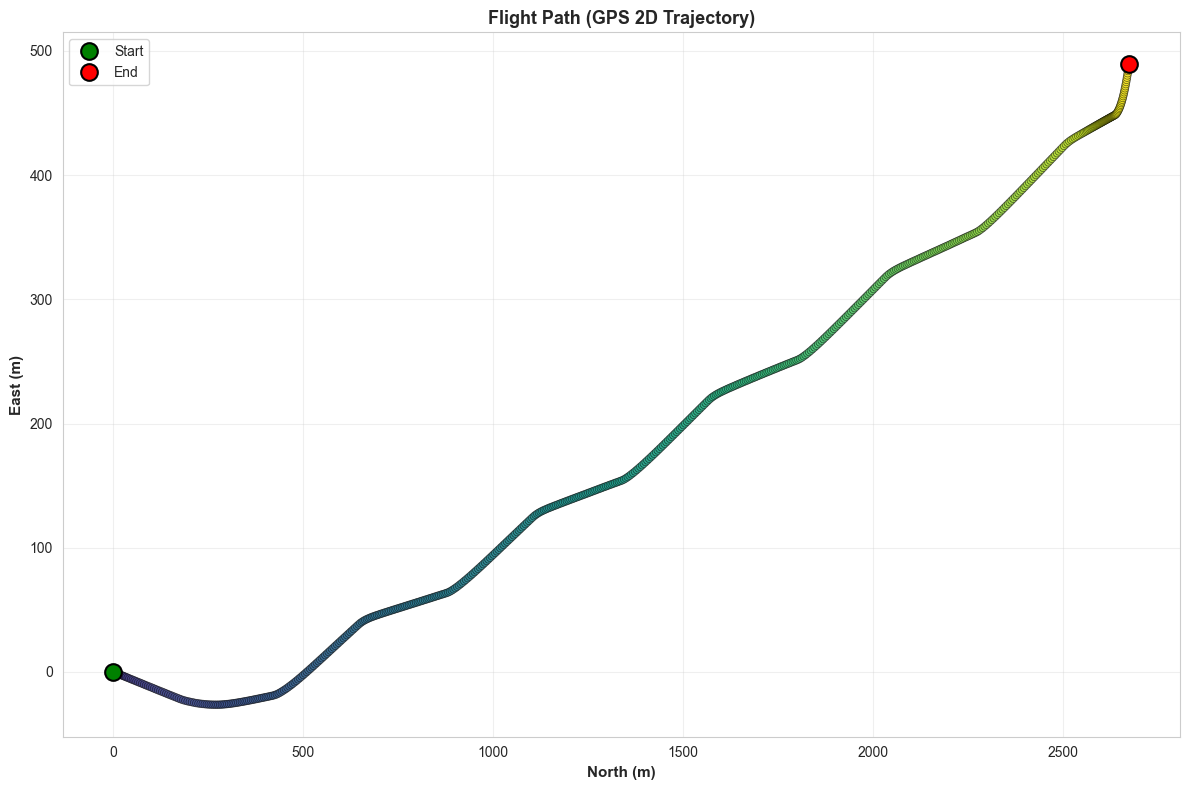

In [13]:
def plot_trajectory(df, t_start=None, t_end=None, title='Flight Path (GPS 2D Trajectory)'):
    """
    Plot GPS trajectory for a time window.
    
    Parameters:
        df: DataFrame with 'North_m', 'East_m', 'time_sec' columns
        t_start: Start time in seconds (None = beginning)
        t_end: End time in seconds (None = end)
        title: Plot title
    """
    # Slice by time
    subset = df.copy()
    if t_start is not None:
        subset = subset[subset['time_sec'] >= t_start]
    if t_end is not None:
        subset = subset[subset['time_sec'] <= t_end]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    scatter = ax.scatter(subset['North_m'], subset['East_m'], 
                         c=subset['time_sec'], cmap='viridis', 
                         s=30, alpha=0.6, edgecolors='black', linewidth=0.5)

#     cbar = plt.colorbar(scatter, ax=ax)
#     cbar.set_label('Time (seconds)', fontsize=11, fontweight='bold')

    ax.plot(subset['North_m'].iloc[0], subset['East_m'].iloc[0], 
            'go', markersize=12, label='Start', markeredgecolor='black', markeredgewidth=1.5)
    ax.plot(subset['North_m'].iloc[-1], subset['East_m'].iloc[-1], 
            'ro', markersize=12, label='End', markeredgecolor='black', markeredgewidth=1.5)

    ax.set_xlabel('North (m)', fontsize=11, fontweight='bold')
    ax.set_ylabel('East (m)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('auto')
    # ax.set_ylim(-30, 0)  
    plt.tight_layout()
    plt.show()


plot_trajectory(gps_df)

## 6. Altitude Profile

## 7. Combined IMU Magnitude Visualization

## 8. Data Summary Statistics